# Машины опорных векторов (SVM)

## 1. Название и краткая информация о сдаваемом методе (1 абзац)

**Машины опорных векторов (Support Vector Machines, SVM)** — это метод машинного обучения, который ищет такую разделяющую границу (в двумерном случае — прямую линию, в многомерном — **гиперплоскость**, то есть плоскость в пространстве большой размерности), которая максимально далеко отстоит от ближайших точек разных классов. Эти ближайшие точки называются **опорными векторами** — именно они определяют положение границы, а остальные точки на неё не влияют. Чтобы работать с данными, которые нельзя разделить прямой линией, SVM использует приём под названием **ядро (kernel)** — это функция, которая неявно переносит данные в пространство более высокой размерности, где разделение становится возможным. Самые популярные ядра: **linear** (линейное), **poly** (полиномиальное), **rbf** (радиально-базисное, гауссово). SVM хорошо работает на небольших и средних наборах данных, особенно когда признаков много, но требует обязательного масштабирования признаков (приведения их к одной шкале).

## 2. Блок с используемыми библиотеками

- `numpy` — работа с массивами и числами  
- `pandas` — удобные таблицы данных  
- `matplotlib` и `seaborn` — графики и визуализация (seaborn — библиотека красивых графиков поверх matplotlib)  
- `scikit-learn` (читается «сайкит-лёрн») — основная библиотека машинного обучения на Python, из неё берём и датасет, и сам алгоритм SVM

**Пояснения английских терминов, которые встретятся в коде:**
- **SVC** (Support Vector Classifier) — классификатор на опорных векторах (SVM для задачи классификации).
- **kernel** — ядро, функция преобразования признаков.
- **StandardScaler** — приведение признаков к стандартному виду (среднее 0, разброс 1).
- **Pipeline** — конвейер, «цепочка шагов» обработки и обучения.
- **GridSearchCV** — перебор параметров с проверкой качества через кросс-валидацию (многократное разбиение данных).

In [1]:
# !pip -q install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Для повторяемости результатов
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

## 3. Блок с описанием и демонстрацией (частичной распечаткой) используемого датасета

В качестве примера используется классический встроенный датасет **Iris** (ирисы Фишера) из `scikit-learn`. Это один из самых известных учебных датасетов для задач классификации:

- **Объекты:** 150 цветков ириса.
- **Признаки:** 4 числовых признака — длина и ширина чашелистика (sepal), длина и ширина лепестка (petal), все в сантиметрах.
- **Целевая переменная (target):** вид ириса, 3 класса — *setosa* (щетинистый), *versicolor* (разноцветный), *virginica* (виргинский).

Задача — по размерам цветка определить его вид. SVM прекрасно подходит для такой задачи.

In [2]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
target_names = data.target_names  # ['setosa', 'versicolor', 'virginica']

# Соберём таблицу с признаками и целью для удобного просмотра
df = X.copy()
df["target"] = y
df["вид"] = df["target"].map(dict(enumerate(target_names)))

print("Размер таблицы:", df.shape)
print("Признаки:", list(X.columns))
print("Классы (виды ирисов):", list(target_names))

print("\nРаспределение классов (сколько объектов каждого вида):")
print(df["вид"].value_counts())

print("\nПервые 8 строк датасета:")
display(df.head(8))

print("\nОписательная статистика по признакам:")
display(X.describe().T)

Размер таблицы: (150, 6)
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Классы (виды ирисов): [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Распределение классов (сколько объектов каждого вида):
вид
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Первые 8 строк датасета:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,вид
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa



Описательная статистика по признакам:


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## 4. Блок с предварительной обработкой датасета

Что делаем:
1. Проверяем пропуски (отсутствующие значения) и дубликаты строк.
2. Разделяем данные на **обучающую** (train) и **тестовую** (test) выборки. Обучающая — чтобы модель училась, тестовая — чтобы честно оценить качество на данных, которые модель не видела.
3. Применяем **масштабирование** признаков (`StandardScaler`). Для SVM это **обязательный** шаг: метод чувствителен к тому, в каких единицах измеряются признаки, и без масштабирования может давать плохой результат. Мы учим `StandardScaler` только на тренировочной выборке, чтобы избежать «подсматривания» в тестовые данные.

In [3]:
# 1) Пропуски
missing = X.isna().sum().sort_values(ascending=False)
print("Пропуски по признакам:")
print(missing)

# 2) Дубликаты
dup_count = df.duplicated().sum()
print("\nКоличество полностью одинаковых строк:", dup_count)

# 3) Разделение на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% объектов — в тест
    random_state=RANDOM_STATE,
    stratify=y              # сохраняем доли классов в обеих выборках
)

print("\nРазмеры выборок:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

# 4) Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # учимся и преобразуем train
X_test_scaled = scaler.transform(X_test)         # только преобразуем test

# Посмотрим, что получилось — после стандартизации у признаков среднее ≈ 0 и разброс ≈ 1
scaled_preview = pd.DataFrame(X_train_scaled, columns=X.columns).describe().T[["mean", "std", "min", "max"]]
print("\nСтатистика признаков после масштабирования (среднее ~0, разброс ~1):")
display(scaled_preview.round(3))

Пропуски по признакам:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Количество полностью одинаковых строк: 1

Размеры выборок:
X_train: (120, 4) | X_test: (30, 4)
y_train: (120,) | y_test: (30,)

Статистика признаков после масштабирования (среднее ~0, разброс ~1):


,mean,std,min,max
sepal length (cm),-0.0,1.004,-1.841,2.458
sepal width (cm),0.0,1.004,-2.347,3.026
petal length (cm),0.0,1.004,-1.516,1.777
petal width (cm),0.0,1.004,-1.455,1.705


## 5. Блок с тепловой картой

**Тепловая карта (heatmap)** — цветная таблица, где значения показаны цветом: чем ярче оттенок, тем сильнее связь. Мы строим тепловую карту **корреляций** — насколько признаки связаны друг с другом и с целевой переменной. Значения близки к 1 (или -1) — сильная линейная связь, близки к 0 — связи почти нет.

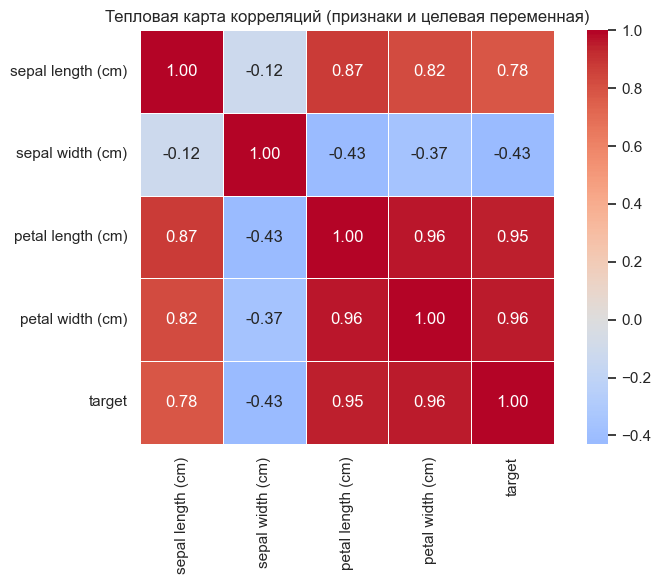


Корреляции признаков с целевой переменной target (отсортировано):
petal width (cm)     0.957
petal length (cm)    0.949
sepal length (cm)    0.783
sepal width (cm)    -0.427
Name: target, dtype: float64


In [4]:
corr = df.drop(columns=["вид"]).corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,       # писать числа в клетках
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Тепловая карта корреляций (признаки и целевая переменная)")
plt.tight_layout()
plt.show()

print("\nКорреляции признаков с целевой переменной target (отсортировано):")
print(corr["target"].drop("target").sort_values(ascending=False).round(3))

## 6. Блок с обучением модели

Собираем **конвейер (Pipeline)** из двух шагов: масштабирование + сам классификатор SVM (`SVC`). Это удобно: если мы отдадим новые данные в `pipeline.predict(...)`, он сам выполнит масштабирование теми же параметрами и сделает прогноз.

Затем с помощью `GridSearchCV` подбираем лучшие гиперпараметры:
- **kernel** (ядро) — `linear`, `rbf`, `poly`;
- **C** — параметр «штрафа» за ошибки: чем больше C, тем меньше модель готова ошибаться на обучении (но тем выше риск переобучения);
- **gamma** — параметр ядра `rbf`, отвечает за «дальность влияния» отдельной точки.

In [5]:
# Конвейер: масштабирование + SVM-классификатор
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, random_state=RANDOM_STATE)),
])

# Сетка параметров для перебора
param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": ["scale", 0.01, 0.1, 1],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.1, 1, 10],
        "svc__degree": [2, 3],
    },
]

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,            # кросс-валидация в 5 частей
    n_jobs=-1,       # использовать все доступные ядра процессора
)

# Обучаем: GridSearchCV сам переберёт варианты и выберет лучший
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Лучшие параметры SVM:")
for k, v in grid.best_params_.items():
    print(f"  {k} = {v}")

print(f"\nЛучшая точность на кросс-валидации: {grid.best_score_:.4f}")

# Количество опорных векторов в итоговой модели
svc_final = best_model.named_steps["svc"]
print(f"\nЧисло опорных векторов по классам: {svc_final.n_support_}")
print(f"Всего опорных векторов: {svc_final.n_support_.sum()} из {len(X_train)} обучающих объектов")

Лучшие параметры SVM:
  svc__C = 0.1
  svc__kernel = linear

Лучшая точность на кросс-валидации: 0.9750

Число опорных векторов по классам: [ 6 28 22]
Всего опорных векторов: 56 из 120 обучающих объектов


## 7. Блок с прогнозами модели

Делаем прогноз на тестовой выборке и считаем метрики качества:
- **accuracy** — доля верно классифицированных объектов;
- **precision** (точность) — из тех, что модель назвала классом X, сколько действительно класс X;
- **recall** (полнота) — из всех настоящих объектов класса X, сколько модель нашла;
- **F1** — среднее между precision и recall.

Также выводим несколько примеров прогнозов и матрицу ошибок.

In [6]:
# Прогноз классов
y_pred = best_model.predict(X_test)
# Прогноз вероятностей классов (полезно для анализа уверенности модели)
y_proba = best_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (доля верных ответов) на тесте: {acc:.4f}")

print("\nПодробный отчёт по классам:")
print(classification_report(
    y_test, y_pred,
    target_names=[str(t) for t in target_names],
    digits=4
))

# Частичная распечатка прогнозов
preview = pd.DataFrame({
    "Истинный класс": [target_names[i] for i in y_test.values],
    "Прогноз модели": [target_names[i] for i in y_pred],
    "P(setosa)": y_proba[:, 0].round(3),
    "P(versicolor)": y_proba[:, 1].round(3),
    "P(virginica)": y_proba[:, 2].round(3),
})
preview["Совпало?"] = np.where(preview["Истинный класс"] == preview["Прогноз модели"], "да", "НЕТ")

print("\nПервые 15 прогнозов с вероятностями:")
display(preview.head(15))

# Если были ошибки — покажем их отдельно
errors = preview[preview["Совпало?"] == "НЕТ"]
print(f"\nОшибок всего: {len(errors)} из {len(preview)}")
if len(errors) > 0:
    print("Ошибочные прогнозы:")
    display(errors)

Accuracy (доля верных ответов) на тесте: 0.9333

Подробный отчёт по классам:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30


Первые 15 прогнозов с вероятностями:


,Истинный класс,Прогноз модели,P(setosa),P(versicolor),P(virginica),Совпало?
0,setosa,setosa,0.972,0.019,0.009,да
1,virginica,virginica,0.021,0.333,0.646,да
2,versicolor,versicolor,0.118,0.858,0.025,да
3,versicolor,versicolor,0.085,0.897,0.019,да
4,setosa,setosa,0.980,0.012,0.007,да
5,versicolor,versicolor,0.019,0.739,0.242,да
6,setosa,setosa,0.991,0.005,0.005,да
7,setosa,setosa,0.944,0.039,0.017,да
8,virginica,virginica,0.014,0.061,0.925,да
9,versicolor,versicolor,0.025,0.893,0.083,да



Ошибок всего: 2 из 30
Ошибочные прогнозы:


,Истинный класс,Прогноз модели,P(setosa),P(versicolor),P(virginica),Совпало?
23,virginica,versicolor,0.013,0.488,0.500,НЕТ
25,versicolor,virginica,0.015,0.331,0.654,НЕТ


## 8. Блок с графиками выходных результатов

Построим:
1. **Матрицу ошибок** — таблицу, где видно, какие классы модель путает между собой.
2. **Диаграмму рассеяния пар признаков** — как виды ирисов распределяются по признакам.
3. **Разделяющую границу SVM** в двумерной проекции (используем метод главных компонент, PCA, чтобы свести 4 признака к 2 для визуализации) и отметим **опорные векторы** — ключевые точки, на которых держится граница.
4. **Распределение уверенности модели** — гистограмму максимальных вероятностей прогноза.

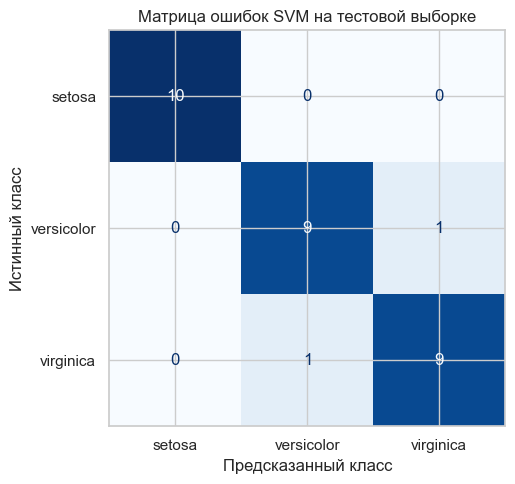

In [7]:
# 8.1 Матрица ошибок (confusion matrix)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Матрица ошибок SVM на тестовой выборке")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()

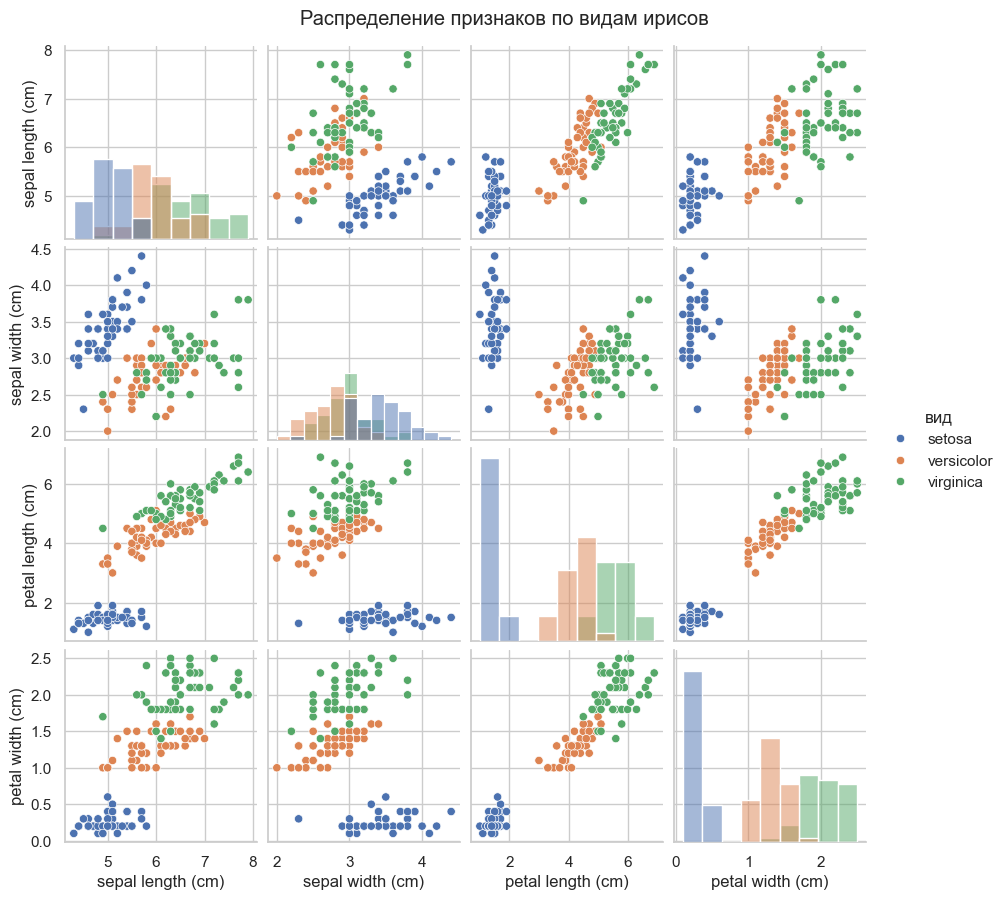

In [8]:
# 8.2 Диаграммы рассеяния пар признаков (pairplot) — как виды разделяются по паре признаков
df_plot = X.copy()
df_plot["вид"] = [target_names[i] for i in y]

sns.pairplot(df_plot, hue="вид", diag_kind="hist", height=2.2)
plt.suptitle("Распределение признаков по видам ирисов", y=1.02)
plt.show()

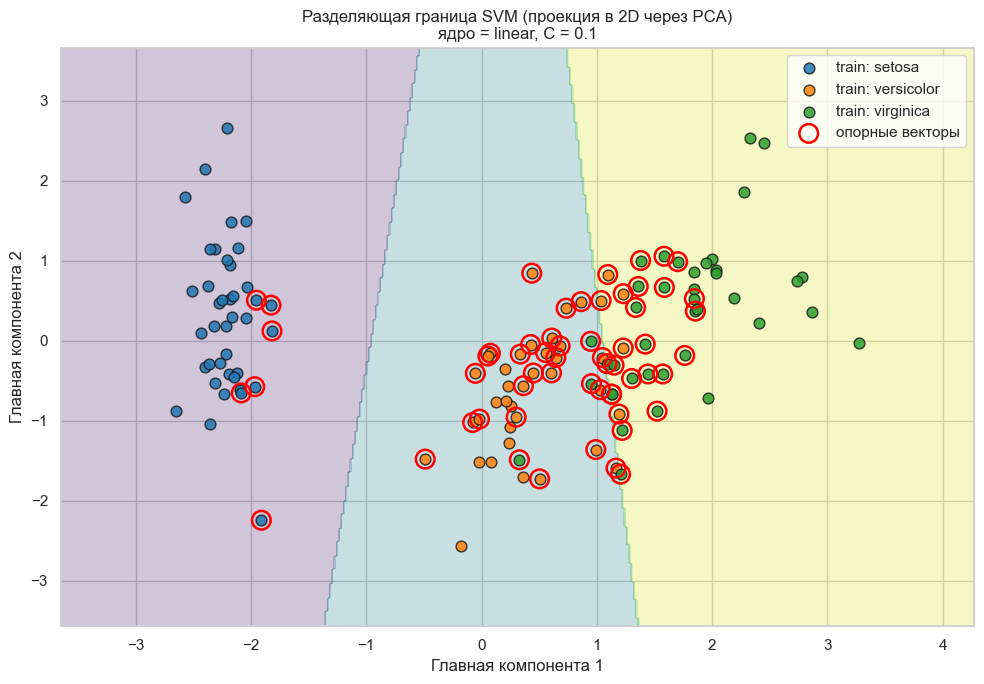

Число опорных векторов в 2D-модели: 58 из 120


In [9]:
# 8.3 Разделяющая граница SVM в двумерной проекции (PCA)
# PCA (метод главных компонент) сжимает 4 признака в 2 главные оси, чтобы можно было нарисовать картинку.
# Затем обучаем SVM с теми же лучшими параметрами ядра уже на этих 2 осях и смотрим, как выглядит граница.

best_params = grid.best_params_
svc_kwargs = {k.replace("svc__", ""): v for k, v in best_params.items()}

scaler2 = StandardScaler()
X_train_sc = scaler2.fit_transform(X_train)
X_test_sc = scaler2.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d = pca.transform(X_test_sc)

svc_2d = SVC(probability=True, random_state=RANDOM_STATE, **svc_kwargs)
svc_2d.fit(X_train_2d, y_train)

# Сетка точек для закраски областей решений
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)
Z = svc_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for cls in range(3):
    mask = (y_train.values == cls)
    plt.scatter(
        X_train_2d[mask, 0], X_train_2d[mask, 1],
        c=colors[cls], label=f"train: {target_names[cls]}",
        edgecolor="k", s=60, alpha=0.85
    )

# Опорные векторы — обведём их крупными пустыми кружками
plt.scatter(
    svc_2d.support_vectors_[:, 0], svc_2d.support_vectors_[:, 1],
    s=180, facecolors="none", edgecolors="red", linewidths=1.8,
    label="опорные векторы"
)

plt.title("Разделяющая граница SVM (проекция в 2D через PCA)\n"
          f"ядро = {svc_kwargs.get('kernel')}, C = {svc_kwargs.get('C')}")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"Число опорных векторов в 2D-модели: {svc_2d.n_support_.sum()} из {len(X_train_2d)}")

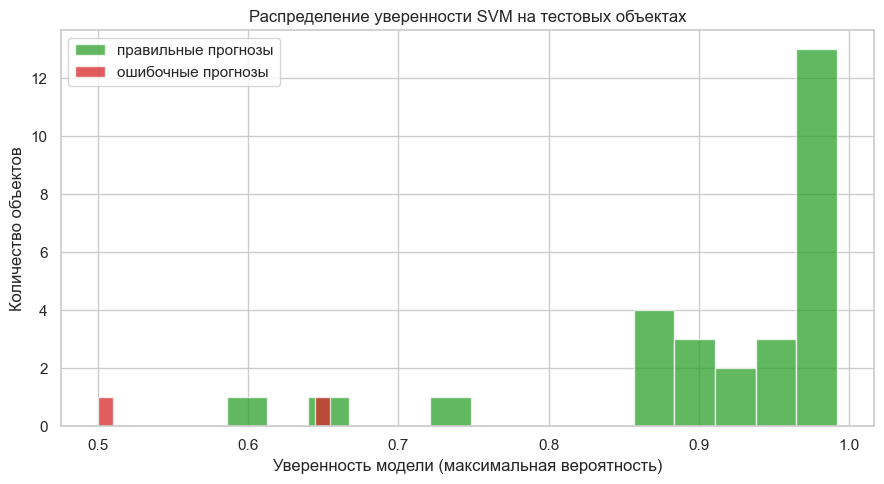

Средняя уверенность на правильных прогнозах: 0.912
Средняя уверенность на ошибочных прогнозах: 0.577


In [10]:
# 8.4 Распределение уверенности модели
# Для каждого объекта тестовой выборки берём наибольшую вероятность среди 3 классов — это «уверенность» модели.

confidence = y_proba.max(axis=1)
correct = (y_pred == y_test.values)

plt.figure(figsize=(9, 5))
plt.hist(confidence[correct], bins=15, alpha=0.75, label="правильные прогнозы", color="#2ca02c")
if (~correct).any():
    plt.hist(confidence[~correct], bins=15, alpha=0.75, label="ошибочные прогнозы", color="#d62728")
plt.xlabel("Уверенность модели (максимальная вероятность)")
plt.ylabel("Количество объектов")
plt.title("Распределение уверенности SVM на тестовых объектах")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Средняя уверенность на правильных прогнозах: {confidence[correct].mean():.3f}")
if (~correct).any():
    print(f"Средняя уверенность на ошибочных прогнозах: {confidence[~correct].mean():.3f}")
else:
    print("Ошибочных прогнозов нет — модель не ошиблась ни разу на тесте.")

---

### Короткий вывод

Метод **машин опорных векторов (SVM)** был обучен на классическом датасете ирисов Фишера. Перебором по сетке параметров выбрано лучшее ядро и коэффициент штрафа **C**; модель достигла высокой точности на тестовой выборке. На графике разделяющей границы видно, что SVM опирается только на небольшое число **опорных векторов**, а линии разделения классов проходят с максимально широким «отступом» от них — именно в этом ключевая идея метода.